# Bending Fitting Function Explained
This notebook takes from a similar format as the Bending_algebra.ipynb notebook but to explain the steps behind the actual bending mode fit calculation or commonly known as the modalCorrection function.

## Setup of environment/coordinates

In [1]:
from pathlib import Path

import numpy as np
import psd_utils
from matplotlib import pyplot as plt
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import RectBivariateSpline

from rfcml_bending import Bending
from rfcml_bending.force_matrix import ForceSpace
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter
import scipy.io as sio

from scipy.io import savemat

import scipy
import cv2

import astropy
from astropy.io import fits

from matplotlib import pyplot as plt, cm
from matplotlib import colors

#maxBendingModes = 10 # defining some arbitary number of bending modes

## Define the inputs for the function

In order to perform a bending mode fit, we need to read in the matrices from the forceSpace file that are results from SVD. For our function, we will define three main inputs.
* forceSpace - data set with matrices from SVD done on interaction matrix of the mirror. 
* mapOnFEGrid - resampled input surface data or unknown that we are trying to fit bending modes to.
* t - number of bending modes defined. 

The number of actuators corresponds to the number of columns in matrix U or the bending mode matrix. So we defined the actuators by the number of columns in the bending mode matrix. 

Define the maximum number of bending modes we are fitting to as the input of our function. 

For the purpose of demonstrating the fit calculation int his notebook, we are just going to fit a bending mode to itself.

After the parameters are set for the fitting function, we mask our input surface map to only index finite values to avoid any NaNs or Inf values. 

Our input surface map is originally a 2D matrix with the shape $N$ x $N$. With resampling done earlier in the fitting code, we interpolate to then be $N^2$ x 1. This is to fit our input surface to the dictionary of bending modes as defined by matrix $U$.



We then define a loop to go through each bending mode and perform a fitting. The loop then goes through the following steps for each bending mode. We will define the number of bending modes as $f$.

1. Populate a stiffness matrix at the $f$ x $f$ position with the inverse of the $S$ matrix from SVD calculation. 
2. The 'bendCoef' variable defined in the fit is calculated by multiplying the transpose of the $U$ matrix taking only the columns up to the number of bending modes $f$ defined. The dimensions of this calculation are [$f$ x $N^2$] x [$N^2$ x 1]. The resulting matrix is [$f$ x 1] which is an array representing how much of each mode are present in the input surface data. 
3. Now we reconstruct the mode given the input surface map information by multiplying the columns of the $U$ matrix up to the amount of bending modes that are being fitted by the 'bendCoef'. The dimensions of this calculation is [$N^2$ x $f$] x [$f$ x 1] so the resulting matrix is [$N^2$ x 1] and we can interpolate back from a 1D array to 2D array.

As for calculating the forces associated with the number of bending modes being fit to the input surface map we multiply the $V$ matrix from SVD by the inverse $S$ matrix. The 'bendCoef' array is also multiplied by the stiffness matrix up to how many bending modes are being fit to to get how much force is being is being applied to each actuator from the bending mode fit.
$F$ $=$ [$166$ x $166$] x [$166$ x $f$] x [$f$ x 1] 

The resulting matrix $F$ has dimensions of [$166$ x 1] which represents how much of force is applied by each actuator for that given bending mode. 166 represents the amount of actuators that are available on the mirror and can be changed depending on what mirror is being used.



No Zern removal
Not fitting modes: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]
Not fitting modes: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 

Text(0.5, 1.0, 'Percent Error')

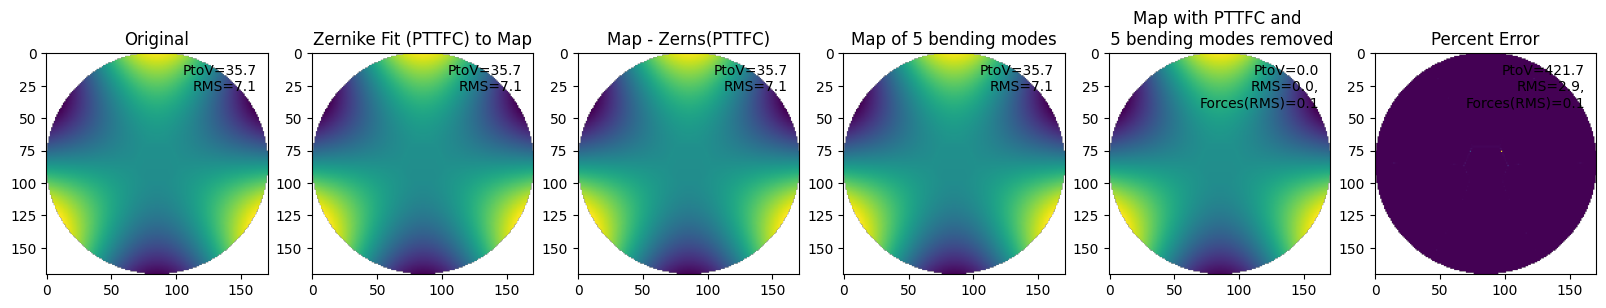

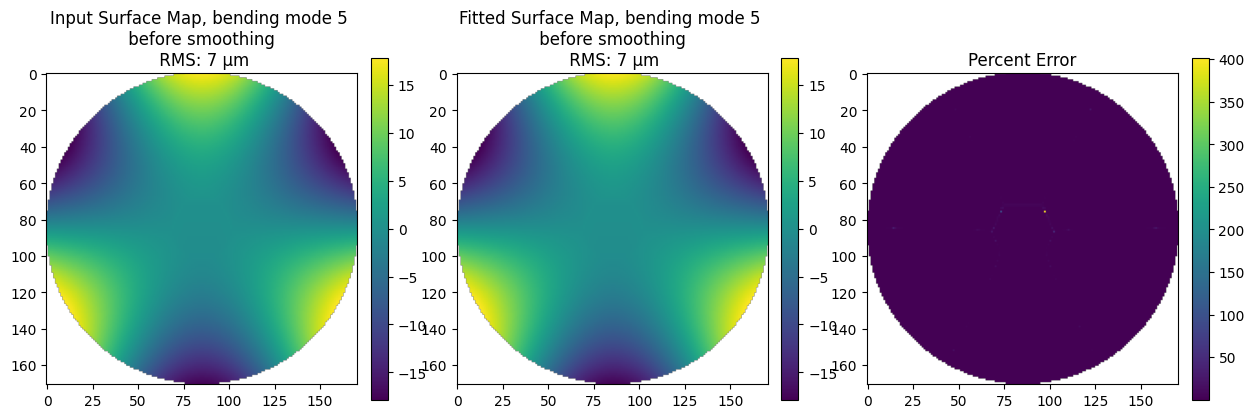

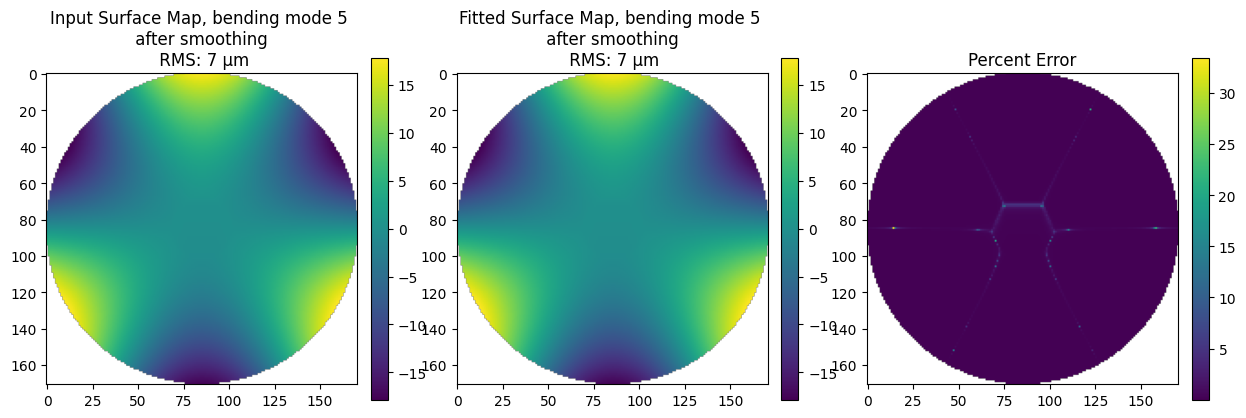

In [2]:
file_path = Path("C:/Users/solva/OneDrive - University of Arizona/Desktop/bending_mode/stp_tel_166_forcespace_mkII.mat")
force_space = ForceSpace(file_path)
#print(force_space.data['U'])

# for f in range(maxBendingModes):
#     actuators = force_space.data['U'].shape[1]
#     sinv = np.zeros((actuators, actuators))


#     mapOnFEGrid = force_space.data['U'][:, f]*1000
#     maskOnFEgrid = np.isfinite(mapOnFEGrid)
#     #print(mapOnFEGrid[maskOnFEgrid])

#     print(f"Input surface shape: {mapOnFEGrid.shape}")

#     sinv[f, f] = 1.0/ force_space.data['S'][f, f] # Create a stiffness matrix

#     print(f"Stiffness matrix shape: {sinv.shape}")

#     bendCoef = np.dot(force_space.data['U'][:, f].T, mapOnFEGrid[maskOnFEgrid])
#     #print(bendCoef)
#     print(f"bendCoef matrix shape: {bendCoef.shape}")

#     forceCoef = np.dot(sinv[:, :f], bendCoef) # Multiply each bending mode coefficient by the stiffness to get how much of each force mode
#     forces = np.dot(force_space.data['V'], forceCoef) # Convert from force modes to actuator forces
#     print(f"forces matrix shape: {forces.shape}")

#     #rmsForces = np.sqrt(np.dot(forces, forces) / actuators) # Calculate RMS force of all actuator forces across the mirror

#     #forces_bal = np.dot(force_space.data['RW_af2lc'], forces) 
#     #forces_bal =  -forces_bal
#     #rmsForces_bal = np.sqrt(np.dot(forces_bal, forces_bal) / actuators)

#     zModeFit = np.dot(force_space.data['U'][:, f], bendCoef)
#     fit = zModeFit 

psd_tools = psd_utils.PSDUtils()

mapOnFEGrid = force_space.data['U'][:, 4]*1000


dims = (171, 171)
xrange = np.max(force_space.data["x_nodes"]) - np.min(force_space.data["y_nodes"])
n_nodes = len(force_space.data["x_nodes"])
dx = xrange / dims[0]
coords = psd_tools.coord_arrays(dims, dx=dx, offset_x=0, offset_y=0)

b_mode = force_space.fea_to_grid(mapOnFEGrid, coords=coords, method="linear")

b = Bending(file_path)
modes = 5
b.bending_mode_correction(map=b_mode, mask=np.isfinite(b_mode), n_modes =modes, dx = dx, coords = coords, plots=True, gauss_remove=False)

b_mode_map_stats = psd_tools.get_map_stats(b_mode, mask = np.isfinite(b_mode), report=False)


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(b_mode)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Input Surface Map, bending mode 5 \n before smoothing \n RMS: {round(b_mode_map_stats.rms)} µm")

rmsForces_bal, b_mode_fit, forces = b.fit_bending(modes_to_fit = np.array([0, 1, 2, 3, 4]), map=mapOnFEGrid)
b_mode_fit = force_space.fea_to_grid(b_mode_fit, coords=coords, method="linear")

fit_map_stats = psd_tools.get_map_stats(b_mode_fit, mask = np.isfinite(b_mode_fit), report=False)

plt.subplot(1, 3, 2)
plt.imshow(b_mode_fit)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Fitted Surface Map, bending mode 5 \n before smoothing \n RMS: {round(fit_map_stats.rms)} µm")

# calculating percent error map
percen_err = np.abs((b_mode_fit - b_mode) / (b_mode)) * 100

perc_stddev = np.nanstd(percen_err)
perc_med = np.nanmedian(percen_err)


#Define bad pixels
bad_mask = percen_err >= 1

# Apply median filter to the entire array
smoothed_fit = median_filter(b_mode_fit, size=3)
smoothed_input = median_filter(b_mode, size=3)

# Replace only bad pixels with smoothed values
fit_corrected = np.where(bad_mask, smoothed_fit, b_mode_fit)
input_corrected = np.where(bad_mask, smoothed_input, b_mode)

# Apply median filter
smoothed_percen_err = median_filter(percen_err, size=3)

# plot percent error after smoothing
plt.subplot(1, 3, 3)
plt.imshow(percen_err)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Percent Error")

fit_map_stats_smooth = psd_tools.get_map_stats(fit_corrected, mask = np.isfinite(fit_corrected), report=False)
input_map_stats_smooth = psd_tools.get_map_stats(input_corrected, mask = np.isfinite(input_corrected), report=False)

percen_err_smooth = np.abs((fit_corrected - input_corrected) / (input_corrected)) * 100

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(input_corrected)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Input Surface Map, bending mode 5 \n after smoothing \n RMS: {round(input_map_stats_smooth.rms)} µm")

plt.subplot(1, 3, 2)
plt.imshow(fit_corrected)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Fitted Surface Map, bending mode 5 \n after smoothing \n RMS: {round(fit_map_stats_smooth.rms)} µm")

# plot percent error after smoothing
plt.subplot(1, 3, 3)
plt.imshow(percen_err_smooth)
plt.colorbar(fraction=0.05, pad=0.04)
plt.title(f"Percent Error")


## how to get bending mode coefficients from a fit

### under construction

Not fitting modes: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]


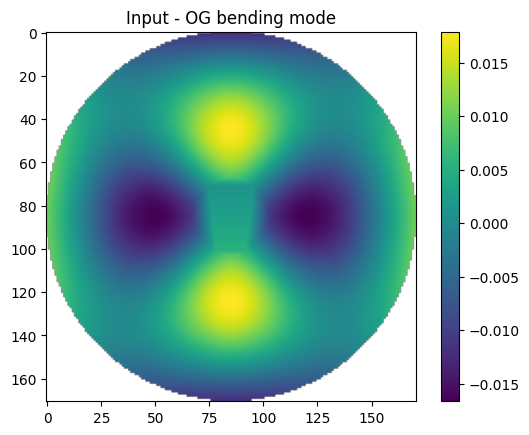

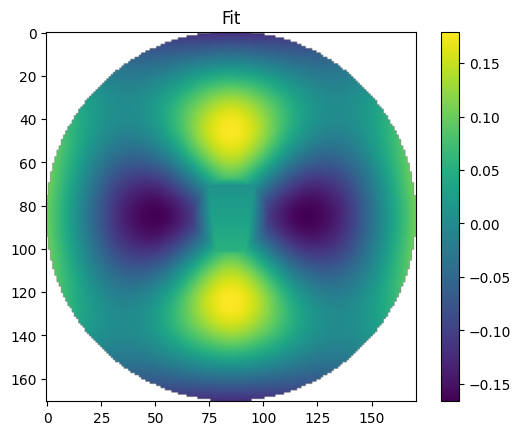

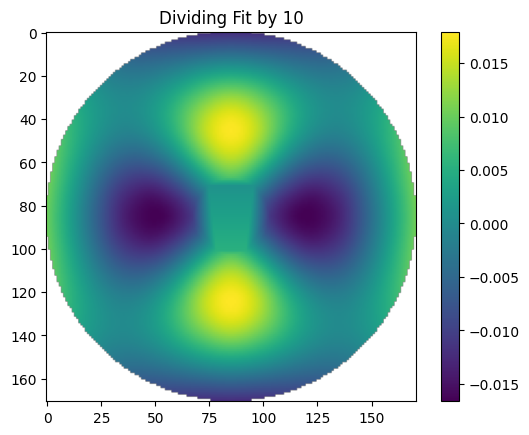

In [3]:
b_mode_input = force_space.data['U'][:, 9]

scaled_bmode = force_space.fea_to_grid(b_mode_input, coords=coords, method="linear")

plt.figure()
plt.imshow(scaled_bmode)
plt.title('Input - OG bending mode')
plt.colorbar()

rmsForces_bal, b_mode_fit, forces = b.fit_bending(modes_to_fit = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), map=b_mode_input*10)
b_mode_fit = force_space.fea_to_grid(b_mode_fit, coords=coords, method="linear")

plt.figure()
plt.imshow(b_mode_fit)
plt.title('Fit')
plt.colorbar()

ratio = b_mode_fit / 10
plt.figure()
plt.imshow(ratio)
plt.title('Dividing Fit by 10')
plt.colorbar()

# PSD analysis for evaluating fit

09/23/2025 10:36:42AM - __psd_utils__ - WARNING - No rms parameter specified. Not performing any psd normalization.


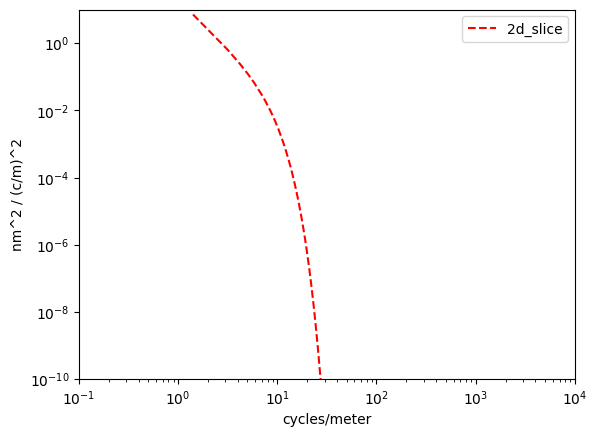

In [ ]:
# generate aberration map

fits_path = 'C:/Users/solva/OneDrive - University of Arizona/Desktop/STP Synthetic Data'
fits_data = sio.loadmat(fits_path + '/wfe_map.mat')
wfe_map = fits_data['data']

# generate a PSD using psd_utils

#map_output = psd_tools.measure_psd(wfe_map, coords = coords)
#print(map_output)

coords = psd_tools.coord_arrays((int(1000), int(1000)), dx=5e-4)

#print(coords)

k = np.logspace(np.log10(0.15), np.log10(4e5), 200)  # [cycles/m]
k_min = np.min(k)
k_max = np.min(k)

test_psd = psd_tools.von_karman_psd(coords, 20.0, 6.5, 2.8,0.15 ,1.0e-12, rms=None, k_min=None, k_max=None, rms_scaling=True, only_1d =False)
 
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
x = test_psd.psd_1d_freqs

#print(x)
y = test_psd.psd_1d

ax.plot(x, y, label="2d_slice", color="red", linestyle="dashed")
ax.set_xlabel("cycles/meter")
ax.set_ylabel("nm^2 / (c/m)^2")

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylim(bottom=1e-10, top=1e1)
ax.set_xlim(left=1e-1, right=1e4)

ax.legend()
#test_psd = psd_tools.create_map(coords, test_map)





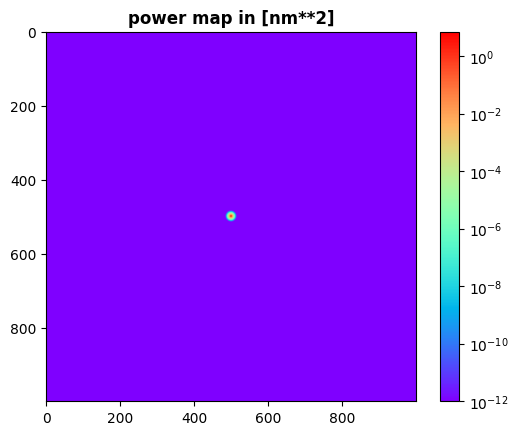

In [128]:
plt.figure()

power = test_psd.psd_2d * coords.dk**2
im = plt.imshow(test_psd.psd_2d, cmap=cm.rainbow, norm=colors.LogNorm())
plt.title("power map in [nm**2]", fontweight="bold")
plt.colorbar(im)
plt.show()

09/23/2025 10:36:47AM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 5.6422e+00
DEBUG:__psd_utils__:RMS of map at end of create_map is: 5.6422e+00


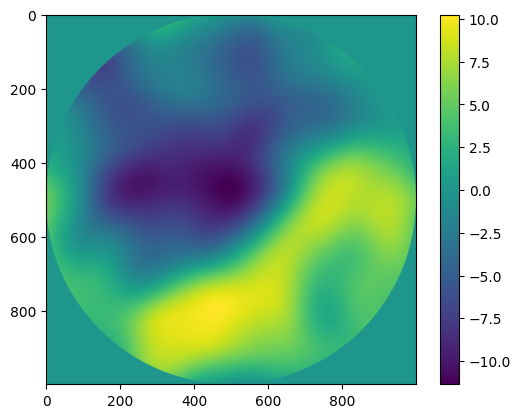

In [129]:
pupil_mask = np.zeros((int(1000), int(1000)))
pupil_mask[coords.r_grid < (0.5 / 2)] = 1
opd = psd_tools.create_map(coords, test_psd, mask=pupil_mask, rms=None)

#opd.map[opd.map == 0] = np.nan

plt.figure()
plt.imshow(opd.map)
plt.colorbar()

#psd_tools.create_plots(map=opd.map, mask=pupil_mask, coords=coords, prefix='test_opd_bending')


In [130]:
meas_psd = psd_tools.measure_psd(opd.map, coords=coords, mask=pupil_mask, max_rad=250)
psd_tools.create_plots( coords=coords, profiles=meas_psd, psd=test_psd, mask=pupil_mask, prefix='test_vk')


09/23/2025 10:36:51AM - __psd_utils__ - INFO - Using the coords array provided.
INFO:__psd_utils__:Using the coords array provided.
09/23/2025 10:36:53AM - __psd_utils__ - DEBUG - Measured total in generated profile: psd_pow1=np.float64(24.99813634609864)
DEBUG:__psd_utils__:Measured total in generated profile: psd_pow1=np.float64(24.99813634609864)
09/23/2025 10:36:53AM - __psd_utils__ - DEBUG - total theoretical profile area from integral = 791816.1097287538
DEBUG:__psd_utils__:total theoretical profile area from integral = 791816.1097287538
09/23/2025 10:36:53AM - __psd_utils__ - DEBUG - Total in theoretical profile: psd_pow2=np.float64(27.074618637228042)
DEBUG:__psd_utils__:Total in theoretical profile: psd_pow2=np.float64(27.074618637228042)
09/23/2025 10:36:53AM - __psd_utils__ - INFO - area scale is 9.233e-01
INFO:__psd_utils__:area scale is 9.233e-01
09/23/2025 10:36:53AM - __psd_utils__ - DEBUG - RMS of map in create_map is: 5.642e+00
DEBUG:__psd_utils__:RMS of map in create_

09/23/2025 10:25:33AM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.


sigma is: 5.000 
RMS is: 5.000 
PTV is: 21.599 
Minimum value is: -11.353 
Maximum value is: 10.246 


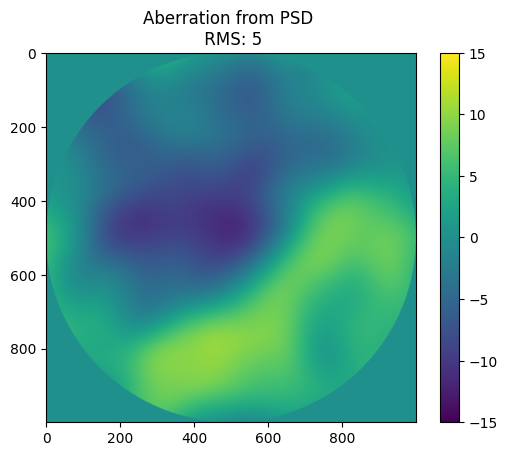

In [113]:
test = cv2.resize(opd.map, (1000, 1000), interpolation=cv2.INTER_AREA)
stats_ab = psd_tools.get_map_stats(test, mask = np.isfinite(test), report=True)

plt.figure()
plt.imshow(test, vmin=-15, vmax=15)
plt.title(f"Aberration from PSD \n RMS: {round(stats_ab.rms)}")
plt.colorbar()

-3256.3
3256.3
(17058, 2)
[-4.96257773 -3.38526294 -1.74494391 ...  3.36350295  3.37182796
  3.32575176]
Not fitting modes: [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]
[-2.72499109 -2.16605952 -1.55559279 ...  5.12383251  5.08835776
  5.17687719]
sigma is: 3.666 
RMS is: 3.679 
PTV is: 18.627 
Minimum value is: -10.286 
Maximum value is: 8.341 


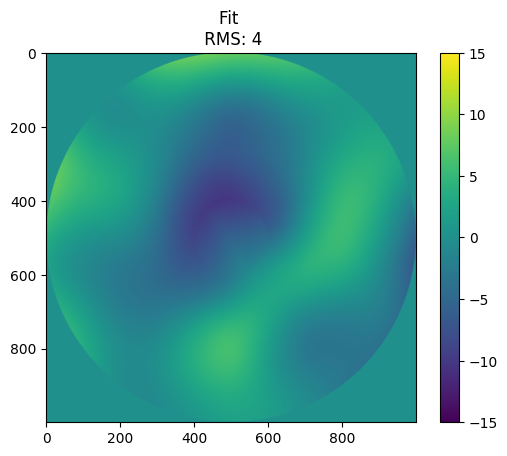

In [131]:
semi_dia = 3256.3
xlin = np.linspace(-semi_dia, semi_dia, opd.map.shape[0])
ylin = np.linspace(-semi_dia, semi_dia, opd.map.shape[1])
xc, yc = np.meshgrid(xlin, ylin)
eff_idx = ~np.isnan(opd.map)


mask = (opd.map != 0)

x_node = force_space.data["x_nodes"]
print(min(x_node))
print(max(x_node))
#x_node = np.arange(len(force_space.data["x_nodes"]))
y_node = force_space.data["y_nodes"]
#y_node = np.arange(len(force_space.data["y_nodes"]))

#list_test = np.column_stack((x_node, y_node))
#print(np.size(list_test))
array_test = list(zip(x_node, y_node))
array_test = np.array(array_test)
print(array_test.shape)


fe_grid = RegularGridInterpolator((xlin, ylin), test)
result = fe_grid(array_test)
#print(np.shape(result))
#np.set_printoptions(threshold=np.inf)
print(result)

rmsForces_bal, b_mode_fit, forces = b.fit_bending(modes_to_fit = np.arange(0, 33), map=result)
print(b_mode_fit)
#b_mode_fit_map = force_space.fea_to_grid(b_mode_fit, coords=coords, method="linear")
b_mode_fit_map = griddata((x_node, y_node), b_mode_fit, (xc, yc))
b_mode_fit_map = b_mode_fit_map

stats_fit = psd_tools.get_map_stats(b_mode_fit_map, mask = np.isfinite(b_mode_fit_map), report=True)
b_mode_fit_map = np.nan_to_num(b_mode_fit_map, nan=0)


plt.figure()
plt.imshow(b_mode_fit_map, vmin=-15, vmax=15)
plt.title(f"Fit \n RMS: {round(stats_fit.rms)}")
plt.colorbar()


In [133]:
bendCoef_input = np.dot(force_space.data["U"][:, :33].T, result)
print(bendCoef_input)

bendCoef_fit = np.dot(force_space.data["U"][:, :33].T, b_mode_fit)
print(bendCoef_fit)

percen_err = np.abs((bendCoef_fit - bendCoef_input) / bendCoef_input) * 100
print(percen_err)

[  14.12302309  -30.21297631 -177.51498227 -219.3368756  -121.70412931
  -12.02774308  221.8039204    10.94604487   87.61915649  -70.94403187
   71.55186649  -37.9735166   -13.10310549   96.39459304  111.20206969
  -68.12890171   12.84993282  -25.36959855  -36.75256462   63.59819041
   36.27501401    0.53476276  -54.83495759   41.90389726  -40.82557895
   32.9934455     9.55517982  -50.15698755  -54.46084692   23.92015842
  -22.81490639   42.37837421  -38.04243923]
[  14.12129142  -30.21291013 -177.51554899 -219.04105061 -121.70435866
  -12.02769769  221.82588973   10.94610221   87.62179725  -70.93079201
   71.55186629  -38.00358785  -13.10308997   96.78252675  111.2299894
  -68.12916775   12.83865786  -25.3689973   -36.751601     63.56474165
   36.28613979    0.53475063  -54.82650235   41.90359627  -40.85517724
   32.99351715    9.55523261  -50.18377297  -54.45982904   23.91993689
  -22.8059415    42.37840876  -37.82614068]
[1.22613255e-02 2.19047728e-04 3.19250519e-04 1.34872435e-01


In [108]:
# now make a PSD from the bending mode fit map
meas_psd = psd_tools.measure_psd(b_mode_fit_map, coords=coords, mask=pupil_mask, max_rad=250)
psd_tools.create_plots( coords=coords, profiles=meas_psd, psd=test_psd, mask=pupil_mask, prefix='test_bmode_fit')

09/23/2025 10:24:10AM - __psd_utils__ - INFO - Using the coords array provided.
INFO:__psd_utils__:Using the coords array provided.
09/23/2025 10:24:12AM - __psd_utils__ - DEBUG - Measured total in generated profile: psd_pow1=np.float64(10.538460274544384)
DEBUG:__psd_utils__:Measured total in generated profile: psd_pow1=np.float64(10.538460274544384)
09/23/2025 10:24:12AM - __psd_utils__ - DEBUG - total theoretical profile area from integral = 791816.1097287538
DEBUG:__psd_utils__:total theoretical profile area from integral = 791816.1097287538
09/23/2025 10:24:12AM - __psd_utils__ - DEBUG - Total in theoretical profile: psd_pow2=np.float64(11.044378211731969)
DEBUG:__psd_utils__:Total in theoretical profile: psd_pow2=np.float64(11.044378211731969)
09/23/2025 10:24:12AM - __psd_utils__ - INFO - area scale is 9.542e-01
INFO:__psd_utils__:area scale is 9.542e-01
09/23/2025 10:24:12AM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.
09/23/2025 10:24:12AM - __psd_utils__

## TESTING

4
(3, 4)
(3, 4)
(3, 4)
(31, 31)
(31, 31)


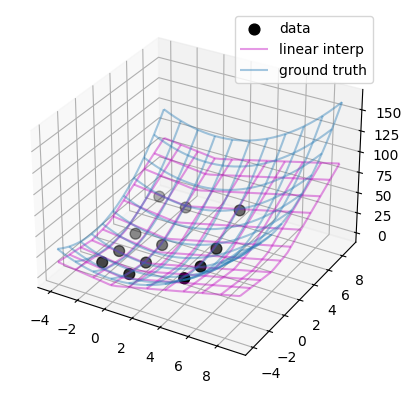

In [ ]:
x, y = np.array([-2, 0, 4]), np.array([-2, 0, 2, 5])
def ff(x, y):
    return x**2 + y**2

print(np.size(y))

xg, yg = np.meshgrid(x, y, indexing='ij')
data = ff(xg, yg)

print(xg.shape)
print(yg.shape)
print(data.shape)

interp = RegularGridInterpolator((x, y), data,
                                 bounds_error=False, fill_value=None)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(xg.ravel(), yg.ravel(), data.ravel(),
           s=60, c='k', label='data')

xx = np.linspace(-4, 9, 31)
yy = np.linspace(-4, 9, 31)
X, Y = np.meshgrid(xx, yy, indexing='ij')

print(X.shape)
print(Y.shape)

# interpolator
ax.plot_wireframe(X, Y, interp((X, Y)), rstride=3, cstride=3,
                  alpha=0.4, color='m', label='linear interp')

# ground truth
ax.plot_wireframe(X, Y, ff(X, Y), rstride=3, cstride=3,
                  alpha=0.4, label='ground truth')
plt.legend()
plt.show()
